# GCAP3226 Week 4 — In-class exercise (5%)

**Individual.** Three tasks + submit (Commit & Push → Moodle GitHub URL).

| Task | Do this |
|------|---------|
| **1** | Percentage change by A&E triage; largest fall / rise; triage 4+5 combined |
| **2** | Grouped bar chart: H1 2025 vs H1 2026 attendances by triage (10 bars) + numbers / percentage change |
| **3** | Short write-up: one supporting point + one gap for the A&E claim |


## Setup

Run the next cell. Data: `w4_ae_triage_h1.csv` (**H1** 2025 vs **H1** 2026 attendances by triage).

**H1** = first half of the year (usually **1 January – 30 June**).

**AI:** `Cmd+I` / `Ctrl+I` on a code cell → implement the comment prompt → **Keep**. Interpretations in your own words.


In [3]:
# Setup — run first
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_FILE = "week4_ae_triage_h1.csv"
path = Path(DATA_FILE) if Path(DATA_FILE).is_file() else Path.cwd() / DATA_FILE
df = pd.read_csv(path)
print("Using:", path.resolve())
df



Using: /workspaces/GCAP3226_week4/week4_ae_triage_h1.csv


,triage,triage_name,attend_h1_2025,attend_h1_2026
0,1,Critical,13848,14541
1,2,Emergency,28554,29981
2,3,Urgent,400428,411994
3,4,Semi-urgent,489032,441974
4,5,Non-urgent,18448,14758


## Task 1 — Percentage change

**Purpose:** Measure how A&E attendances changed from H1 2025 to H1 2026 for each triage group, so you can see which groups rose or fell before judging the A&E claim in Task 3.

1. Add a column `pct_change` = `(attend_h1_2026 - attend_h1_2025) / attend_h1_2025 * 100`.
2. Show the table.
3. Print the triage with the **largest fall** and the **largest rise**.
4. Compute the percentage change for triage **4+5 combined** (sum attendances first, then apply the same formula).

Then, in the next cell, write **1–2 sentences** answering:
- Did triage **1–2** (Critical / Emergency) mainly **rise or fall**?
- Did triage **4–5** (Semi-urgent / Non-urgent) mainly **rise or fall**?
- In one short phrase: what does that pattern look like for the A&E claim (lower-urgency down; critical/emergency protected)?


In [5]:
# Task 1
#
# Input: df (triage, triage_name, attend_h1_2025, attend_h1_2026)
# Process: Write Python code to add pct_change, display the table,
#          print largest fall and largest rise; also 4+5 combined percentage change
# Output: table + printed fall/rise + 4+5 combined
#
# YOUR CODE BELOW

df["pct_change"] = (
    (df["attend_h1_2026"] - df["attend_h1_2025"])
    / df["attend_h1_2025"]
    * 100
)
display(df)

largest_fall = df.loc[df["pct_change"].idxmin()]
largest_rise = df.loc[df["pct_change"].idxmax()]

print(
    f"Largest fall: Triage {int(largest_fall['triage'])} "
    f"({largest_fall['triage_name']}), {largest_fall['pct_change']:.2f}%"
)
print(
    f"Largest rise: Triage {int(largest_rise['triage'])} "
    f"({largest_rise['triage_name']}), {largest_rise['pct_change']:.2f}%"
)

triage_45 = df[df["triage"].isin([4, 5])]
combined_2025 = triage_45["attend_h1_2025"].sum()
combined_2026 = triage_45["attend_h1_2026"].sum()
combined_pct_change = (combined_2026 - combined_2025) / combined_2025 * 100

print(f"Triage 4+5 combined percentage change: {combined_pct_change:.2f}%")

,triage,triage_name,attend_h1_2025,attend_h1_2026,pct_change
0,1,Critical,13848,14541,5.004333
1,2,Emergency,28554,29981,4.997549
2,3,Urgent,400428,411994,2.888409
3,4,Semi-urgent,489032,441974,-9.622683
4,5,Non-urgent,18448,14758,-20.002168


Largest fall: Triage 5 (Non-urgent), -20.00%
Largest rise: Triage 1 (Critical), 5.00%
Triage 4+5 combined percentage change: -10.00%


In [8]:
# Task 1 note
task1_note = """
Triage 1–2 mainly rose: Critical increased by 5.00% and Emergency by 5.00%.
Triage 4–5 mainly fell: Semi-urgent decreased by 9.62% and Non-urgent by 20.00%, with a combined fall of 10.00%. This pattern supports the A&E claim that lower-urgency attendances fell while critical/emergency care remained protected.
"""
print(task1_note)


Triage 1–2 mainly rose: Critical increased by 5.00% and Emergency by 5.00%.
Triage 4–5 mainly fell: Semi-urgent decreased by 9.62% and Non-urgent by 20.00%, with a combined fall of 10.00%. This pattern supports the A&E claim that lower-urgency attendances fell while critical/emergency care remained protected.



## Task 2 — Visualization

**Purpose:** Turn the Task 1 table into a **grouped bar chart** that compares H1 2025 and H1 2026 attendances for each triage (5 groups, 2 bars each → 10 bars), and makes the **numbers** and **percentage change** easy to see.

In the next code cell, write your own IPO comment prompt, then use Inline Chat to implement it. Interpretations stay in your own words.


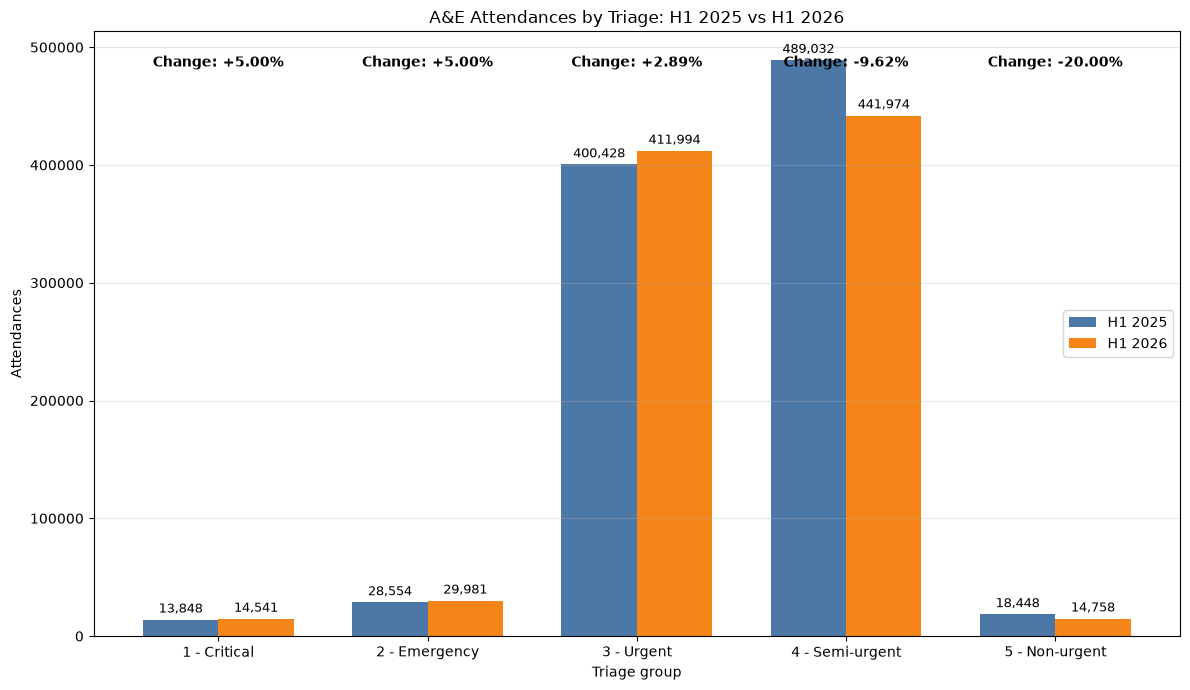

In [9]:
# Task 2 — grouped bar chart
#
# Input: Task 1 table df, including pct_change
# Process: Create 5 triage groups with two bars per group for H1 2025 and H1 2026.
#          Add attendance labels to each bar and percentage-change labels above each group.
# Output: A chart showing attendance numbers and percentage changes.
#
# YOUR CODE BELOW

import numpy as np

x = np.arange(len(df))
bar_width = 0.36

fig, ax = plt.subplots(figsize=(12, 7))
bars_2025 = ax.bar(
    x - bar_width / 2,
    df["attend_h1_2025"],
    bar_width,
    label="H1 2025",
    color="#4C78A8",
)
bars_2026 = ax.bar(
    x + bar_width / 2,
    df["attend_h1_2026"],
    bar_width,
    label="H1 2026",
    color="#F58518",
)

ax.bar_label(
    bars_2025,
    labels=[f"{value:,.0f}" for value in df["attend_h1_2025"]],
    padding=3,
    fontsize=9,
)
ax.bar_label(
    bars_2026,
    labels=[f"{value:,.0f}" for value in df["attend_h1_2026"]],
    padding=3,
    fontsize=9,
)

for position, percentage in zip(x, df["pct_change"]):
    ax.text(
        position,
        ax.get_ylim()[1] * 0.96,
        f"Change: {percentage:+.2f}%",
        ha="center",
        va="top",
        fontsize=10,
        fontweight="bold",
    )

ax.set_title("A&E Attendances by Triage: H1 2025 vs H1 2026")
ax.set_xlabel("Triage group")
ax.set_ylabel("Attendances")
ax.set_xticks(x)
ax.set_xticklabels(
    [f"{triage} - {name}" for triage, name in zip(df["triage"], df["triage_name"])]
)
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

## Task 3 — Write-up

**Claim:** After fee reform, A&E improved — lower-urgency attendances fell; critical/emergency care stayed protected; urgent care became more efficient.

You may also cite: triage III within 30 min **81.4 → 88.5** (percentage); mean wait **23 → 20** min.

**3a** — Write **one supporting point** (cite a number) and **one gap** in the evidence.

**3b** — 2–4 sentences: how well is the claim supported by the published evidence (your table / chart, and any figures cited above)?


In [1]:
# Task 3
task3a = """
3a SUPPORT (1 point, cite a number):
Non-urgent A&E attendances fell by 20%, from 18,448 in H1 2025 to 14,758 in H1 2026; meanwhile, Critical and Emergency attendances each rose by 5%.

3a GAP (1 point):
The evidence is only a before-and-after comparison: it does not show where patients went after the fall in lower-urgency attendances, whether any care was delayed or unmet, or whether the reform caused the change.
"""

task3b = """
3b:
The claim is partially supported. The table/chart shows that lower-urgency attendances fell, especially non-urgent attendances by 20%, while Critical and Emergency attendances each increased by 5%; triage III performance also improved, with the share seen within 30 minutes rising from 81.4% to 88.5% and mean wait falling from 23 to 20 minutes. However, the published evidence is a short before-and-after comparison without a counterfactual or evidence about diverted, delayed, or unmet care, so it cannot establish that the fee reform itself caused all of the improvement or fully proved that care remained protected.
"""

print(task3a)
print("---")
print(task3b)



3a SUPPORT (1 point, cite a number):
Non-urgent A&E attendances fell by 20%, from 18,448 in H1 2025 to 14,758 in H1 2026; meanwhile, Critical and Emergency attendances each rose by 5%.

3a GAP (1 point):
The evidence is only a before-and-after comparison: it does not show where patients went after the fall in lower-urgency attendances, whether any care was delayed or unmet, or whether the reform caused the change.

---

3b:
The claim is partially supported. The table/chart shows that lower-urgency attendances fell, especially non-urgent attendances by 20%, while Critical and Emergency attendances each increased by 5%; triage III performance also improved, with the share seen within 30 minutes rising from 81.4% to 88.5% and mean wait falling from 23 to 20 minutes. However, the published evidence is a short before-and-after comparison without a counterfactual or evidence about diverted, delayed, or unmet care, so it cannot establish that the fee reform itself caused all of the improveme

## Submit

1. Save → Source Control → **Commit & Push**  
2. Moodle: paste your **GitHub URL**
